<a href="https://colab.research.google.com/github/MarlzRana/machine-learning/blob/main/recurrent_unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Marlin's Recurrent UNet

In [ ]:
import os

import torch

from torch.utils.data import Dataset
from torch import nn
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torchvision import transforms

import matplotlib.pyplot as plt

import cv2

import numpy as np

import albumentations as A

from typing import List, Dict

In [ ]:
DEVICE=torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

## Basic Modules

In [ ]:
class Conv2dBatchNorm(nn.Module):
  def __init__(
      self,
      in_channels,
      out_channels,
      kernel_size,
      stride=1,
      padding=0,
    ):

    super().__init__()

    self.conv = nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size,
        stride=stride,
        padding=padding,
        bias=False
    )

    self.batch_norm = nn.BatchNorm2d(out_channels)

  def forward(self, x):
    out_conv = self.conv(x)
    out_batch_norm = self.batch_norm(out_conv)

    return out_batch_norm

In [ ]:
class Conv2dBatchNormReLU(nn.Module):
  def __init__(
      self,
      in_channels,
      out_channels,
      kernel_size,
      stride=1,
      padding=0,
    ):

    super().__init__()

    self.conv = nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size,
        stride=stride,
        padding=padding,
        bias=False
    )

    self.batch_norm = nn.BatchNorm2d(out_channels)

    self.relu = nn.ReLU(inplace=True)


  def forward(self, x):
    out_conv = self.conv(x)
    out_batch_norm = self.batch_norm(out_conv)
    self.relu(out_batch_norm)

    return out_batch_norm

In [ ]:
class Conv2dGroupNorm(nn.Module):
  def __init__(
      self,
      in_channels,
      out_channels,
      kernel_size,
      stride=1,
      padding=0,
      num_groups=8
    ):

    super().__init__()

    self.conv = nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size,
        stride=stride,
        padding=padding,
        bias=False
    )

    self.group_norm = nn.GroupNorm(num_groups, out_channels)

  def forward(self, x):
    out_conv = self.conv(x)
    out_group_norm = self.group_norm(out_conv)

    return out_group_norm

In [ ]:
class Conv2dGroupNormReLU(nn.Module):
  def __init__(
      self,
      in_channels,
      out_channels,
      kernel_size,
      stride=1,
      padding=0,
      num_groups=8
    ):

    super().__init__()

    self.conv = nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size,
        stride=stride,
        padding=padding,
        bias=False
    )

    self.group_norm = nn.GroupNorm(num_groups, out_channels)

    self.relu = nn.ReLU(inplace=True)


  def forward(self, x):
    out_conv = self.conv(x)
    out_group_norm = self.group_norm(out_conv)
    self.relu(out_group_norm)

    return out_group_norm

## RecurrentUNetBlock

In [ ]:
class RecurrentUNetBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.conv_1 = Conv2dGroupNormReLU(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=3,
        padding=1,
    )

    self.conv_2 = Conv2dGroupNormReLU(
        in_channels=out_channels,
        out_channels=out_channels,
        kernel_size=3,
        padding=1,
    )

  def forward(self, x):
    out_conv_1 = self.conv_1(x)
    out_conv_2 = self.conv_2(out_conv_1)

    return out_conv_2

## RecurrentEncoder

In [ ]:
class RecurrentUNetEncoder(nn.Module):
  def __init__(self, channels:List[int], max_pool_conf: Dict):
    super().__init__()

    assert "kernel_size" in max_pool_conf, "c:ModUNetEncoder p:max_pool_conf need to have a kernel_size key"
    assert "stride" in max_pool_conf, "c:ModUNetEncoder p:max_pool_conf need to have a stride key"
    assert "padding" in max_pool_conf, "c:ModUNetEncoder p:max_pool_conf need to have a padding key"

    self.channels = channels
    self.max_pool_conf = max_pool_conf

    self.module_list = nn.ModuleList()

    self.block_1 = RecurrentUNetBlock(
        in_channels=self.channels[0],
        out_channels=self.channels[1],
    )

    self.max_pool_1 = nn.MaxPool2d(
        kernel_size=self.max_pool_conf["kernel_size"],
        stride=self.max_pool_conf["stride"],
        padding=self.max_pool_conf["padding"]
    )

    self.block_2 = RecurrentUNetBlock(
        in_channels=self.channels[1],
        out_channels=self.channels[2],
    )
    self.max_pool_2 = nn.MaxPool2d(
        kernel_size=self.max_pool_conf["kernel_size"],
        stride=self.max_pool_conf["stride"],
        padding=self.max_pool_conf["padding"]
    )

    self.block_3 = RecurrentUNetBlock(
        in_channels=self.channels[2],
        out_channels=self.channels[3]
    )
    self.max_pool_3 = nn.MaxPool2d(
        kernel_size=self.max_pool_conf["kernel_size"],
        stride=self.max_pool_conf["stride"],
        padding=self.max_pool_conf["padding"]
    )

    self.block_4 = RecurrentUNetBlock(
        in_channels=self.channels[3],
        out_channels=self.channels[4]
    )


  def forward(self, x):
    out_block_1 = self.block_1(x)
    out_max_pool_1 = self.max_pool_1(out_block_1)

    out_block_2 = self.block_2(out_max_pool_1)
    out_max_pool_2 = self.max_pool_2(out_block_2)

    out_block_3 = self.block_3(out_max_pool_2)
    out_max_pool_3 = self.max_pool_3(out_block_3)

    out_block_4 = self.block_4(out_max_pool_3)

    return (out_block_4, out_block_3, out_block_2, out_block_1)


# enc_out = MarlinUNetEncoder(channels=[3, 64, 128, 256, 512, 1024], max_pool_conf={"kernel_size": 3, "stride": 2, "padding": 1})(torch.randn(1, 3, 256, 256))


# for out in enc_out:
#   print(out.shape)

## MarlinUNetCenter

In [ ]:
class RecurrentUNetCenter(nn.Module):
  def __init__(self, channels:List[int], max_pool_conf:Dict, up_conv_conf: dict):
    super().__init__()

    assert len(channels) == 6, "c:ModUNetCenter p:channels needs to be of length 6"

    assert "kernel_size" in max_pool_conf, "c:ModUNetCenter p:max_pool_conf need to have a kernel_size key"
    assert "stride" in max_pool_conf, "c:ModUNetCenter p:max_pool_conf need to have a stride key"
    assert "padding" in max_pool_conf, "c:ModUNetCenter p:max_pool_conf need to have a padding key"

    assert "kernel_size" in up_conv_conf, "c:ModUNetCenter p:up_conv_conf need to have a kernel_size key"
    assert "stride" in up_conv_conf, "c:ModUNetCenter p:up_conv_conf need to have a stride key"
    assert "padding" in up_conv_conf, "c:ModUNetCenter p:up_conv_conf need to have a padding key"

    self.channels = channels
    self.max_pool_conf = max_pool_conf
    self.up_conv_conf = up_conv_conf

    self.max_pool_1 = nn.MaxPool2d(
        kernel_size=self.max_pool_conf["kernel_size"],
        stride=self.max_pool_conf["stride"],
        padding=self.max_pool_conf["padding"]
    )

    self.block_1 = RecurrentUNetBlock(
        in_channels=self.channels[4],
        out_channels=self.channels[5],
    )

    self.up_conv_1 = nn.ConvTranspose2d(
        in_channels=self.channels[5],
        out_channels=self.channels[4],
        kernel_size=self.up_conv_conf["kernel_size"],
        stride=self.up_conv_conf["stride"],
        padding=self.up_conv_conf["padding"]
    )

  def forward(self, x):
    out_max_pool_1 = self.max_pool_1(x)
    out_block_1 = self.block_1(out_max_pool_1)

    return self.up_conv_1(out_block_1)

## MarlinUNetDecoder

In [ ]:
class RecurrentUNetDecoder(nn.Module):
  def __init__(
      self,
      channels:List[int],
      up_conv_conf:Dict,
    ):
    super().__init__()

    assert len(channels) == 6, "c:ModUNetEncoder p:channels needs to be of length 6"

    assert "kernel_size" in up_conv_conf, "c:ModUNetDecoder p:up_conv_conf need to have a kernel_size key"
    assert "stride" in up_conv_conf, "c:ModUNetDecoder p:up_conv_conf need to have a stride key"
    assert "padding" in up_conv_conf, "c:ModUNetDecoder p:up_conv_conf need to have a padding key"

    self.channels = channels
    self.up_conv_conf = up_conv_conf

    self.block_1 = RecurrentUNetBlock(
        in_channels=self.channels[5],
        out_channels=self.channels[4]
    )
    self.up_conv_1 = nn.ConvTranspose2d(
        in_channels=self.channels[4],
        out_channels=self.channels[3],
        kernel_size=self.up_conv_conf["kernel_size"],
        stride=self.up_conv_conf["stride"],
        padding=self.up_conv_conf["padding"],
    )

    self.block_2 = RecurrentUNetBlock(
        in_channels=self.channels[4],
        out_channels=self.channels[3],
    )
    self.up_conv_2 = nn.ConvTranspose2d(
        in_channels=self.channels[3],
        out_channels=self.channels[2],
        kernel_size=self.up_conv_conf["kernel_size"],
        stride=self.up_conv_conf["stride"],
        padding=self.up_conv_conf["padding"]
    )

    self.block_3 = RecurrentUNetBlock(
        in_channels=self.channels[3],
        out_channels=self.channels[2]
    )
    self.up_conv_3 = nn.ConvTranspose2d(
        in_channels=self.channels[2],
        out_channels=self.channels[1],
        kernel_size=self.up_conv_conf["kernel_size"],
        stride=self.up_conv_conf["stride"],
        padding=self.up_conv_conf["padding"]
    )

    self.block_4 = RecurrentUNetBlock(
        in_channels=self.channels[2],
        out_channels=self.channels[1]
    )


  def __resize_and_join(self, prev_feature_map, x):
    fixed_x = transforms.Resize(size=(prev_feature_map.shape[2], prev_feature_map.shape[3]), antialias=False)(x)
    return torch.cat((prev_feature_map, fixed_x), dim=1)

  def forward(self, x, prev_feature_maps):
    out_block_1 = self.block_1(self.__resize_and_join(prev_feature_maps[0], x))
    out_up_conv_1 = self.up_conv_1(out_block_1)

    out_block_2 = self.block_2(self.__resize_and_join(prev_feature_maps[1], out_up_conv_1))
    out_up_conv_2 = self.up_conv_2(out_block_2)

    out_block_3 = self.block_3(self.__resize_and_join(prev_feature_maps[2], out_up_conv_2))
    out_up_conv_3 = self.up_conv_3(out_block_3)

    out_block_4 = self.block_4(self.__resize_and_join(prev_feature_maps[3], out_up_conv_3))

    return out_block_4

## RecurrentUNetTail

In [ ]:
class RecurrentUNetTail(nn.Module):
  def __init__(self, num_classes, channels: List[int]):
    super().__init__()

    assert len(channels) == 6, "c:ModUNetTail p:channels needs to be of length 6"

    self.channels = channels

    self.segmentation_tail = nn.Conv2d(
        in_channels=self.channels[1],
        out_channels=num_classes,
        kernel_size=1
    )

    self.activation_fn = nn.Sigmoid()

  def forward(self, x):
    return self.activation_fn(self.segmentation_tail(x))

## RecurrentUNetWithoutTail

In [ ]:
class RecurrentUNetWithoutTail(nn.Module):
  def __init__(
      self,
      channels: List[int]=[3, 64, 128, 256, 512, 1024],
      max_pool_conf: Dict={"kernel_size": 3, "stride": 2, "padding": 1},
      up_conv_conf: Dict={"kernel_size": 3, "stride": 2, "padding": 1},
      dropout_rate: float=0.2
    ):
    super().__init__()

    self.channels = channels
    self.max_pool_conf = max_pool_conf
    self.up_conv_conf = up_conv_conf


    self.enc = RecurrentUNetBlock(
        channels=channels,
        max_pool_conf=max_pool_conf
    )

    self.dropout = nn.Dropout2d(p=dropout_rate)

    self.center = RecurrentUNetBlock(
        channels=self.channels,
        max_pool_conf=self.max_pool_conf,
        up_conv_conf=self.up_conv_conf
    )

    self.dec = RecurrentUNetBlock(
        channels=self.channels,
        up_conv_conf=self.up_conv_conf,
    )

  def forward(self, x):
    out_enc = self.enc(x)
    out_center = self.center(self.dropout(out_enc[0]))
    out_dec = self.dec(out_center, out_enc)

    return out_dec

## Testing

In [ ]:
# x = torch.randn(1, 3, 256, 256)
# channels = [3, 64, 128, 256, 512, 1024]
# max_pool_conf = {"kernel_size": 3, "stride": 2, "padding": 1}
# up_conv_conf = {"kernel_size": 3, "stride": 2, "padding": 1}
# num_classes=8

# enc_out = MarlinUNetEncoder(channels=channels, max_pool_conf=max_pool_conf)(x)

# print("Encoder output shapes:")
# for out in enc_out:
#   print(out.shape)
# print()

# center_out = MarlinUNetCenter(channels=channels, max_pool_conf=max_pool_conf, up_conv_conf=up_conv_conf)(enc_out[0])
# print(f"center_out.shape: {center_out.shape}")
# print()

# dec_out = MarlinUNetDecoder(channels=channels, up_conv_conf=up_conv_conf)(center_out, enc_out)
# print(f"dec_out.shape: {dec_out.shape}")
# print()

# tail_out = MarlinUNetTail(num_classes=num_classes, channels=channels)(dec_out)
# print(f"tail_out.shape: {tail_out.shape}")
# print()


In [ ]:
# x = torch.randn(1, 3, 256, 256)
# channels = [3, 64, 128, 256, 512, 1024]
# max_pool_conf = {"kernel_size": 3, "stride": 2, "padding": 1}
# up_conv_conf = {"kernel_size": 3, "stride": 2, "padding": 1}

# without_tail_model_out = MarlinUNetWithoutTail()(x)

# print(f"without_tail_model_out:{without_tail_model_out.shape}")

## RecurrentSRUUNetCell

In [ ]:
# x = torch.randn(1, 3, 256, 256)
# channels = [3, 64, 128, 256, 512, 1024]
# hidden_size=64
# num_classes=8

class RecurrentSRU(nn.Module):
  def __init__(self, in_channels, hidden_channels, out_channels):
    super().__init__()

    self.in_channels = in_channels
    self.hidden_channels = hidden_channels
    self.out_channels = out_channels

    self.update_gate = RecurrentUNetBlock(
        in_channels=self.in_channels,
        out_channels=self.hidden_channels
    )
    self.content_gate = RecurrentUNetBlock(
        in_channels=self.in_channels,
        out_channels=self.hidden_channels
    )

    self.out_conv = nn.Conv2d(
        in_channels=self.hidden_channels,
        out_channels=self.out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

  def forward(self, x, prev_state=None):
    out_update_gate = torch.sigmoid(self.update_gate(x))
    out_content_gate = torch.tanh(self.content_gate(x))

    if prev_state is None:
      state_size = [x.shape[0], self.hidden_channels] + list(x.shape[2:])
      prev_state = torch.ones(state_size).to(DEVICE)

    new_state = prev_state * (1 - out_update_gate) + out_content_gate * out_update_gate
    output = self.out_conv(new_state)
    return output, new_state

# bench_sru_cell = MarlinSRU(
#     in_channels=3,
#     hidden_channels=16,
#     out_channels=32
# )

# output, new_state = bench_sru_cell(torch.randn(1, 3, 256, 256))

# print(f"output.shape{output.shape}")
# print(f"new_state.shape{new_state.shape}")

# print(MarlinSRUUNetCell(channels=channels, num_classes=num_classes)(x)[0].shape)
# print(MarlinSRUUNetCell(channels=channels, num_classes=num_classes)(x)[1].shape)

## RecurrentSRUUNet

In [ ]:
class RecurrentSRUUNetCell(nn.Module):
  def __init__(self, channels):
    super().__init__()
    self.channels = channels

    max_pool_conf = {"kernel_size": 3, "stride": 2, "padding": 1}
    up_conv_conf = {"kernel_size": 3, "stride": 2, "padding": 1}

    self.enc = RecurrentUNetEncoder(channels, max_pool_conf=max_pool_conf)

    self.cell = RecurrentSRU(
        in_channels=channels[4],
        hidden_channels=channels[3],
        out_channels=channels[4]
    )

    self.dec = RecurrentUNetDecoder(channels, up_conv_conf)

  def forward(self, x, prev_state=None):
    enc_out = self.enc(x)

    center_out, new_state = self.cell(enc_out[0], prev_state)

    dec_out = self.dec(center_out, enc_out)

    return dec_out, new_state

In [ ]:
class RecurrentSRURNN(nn.Module):
  def __init__(self, channels, num_classes, non_temp_model, is_non_temp_trainable, is_teacher_forcing):
    super().__init__()
    self.channels = channels
    self.num_classes = num_classes
    self.is_non_temp_trainable = is_non_temp_trainable
    self.is_teacher_forcing = is_teacher_forcing

    self.cell = RecurrentSRUUNetCell(channels=channels)

    self.conv_output = nn.Conv2d(
        in_channels=self.channels[1],
        out_channels=num_classes,
        kernel_size=1
    )

    self.non_temp_model = non_temp_model


    if not self.is_non_temp_trainable:
      for param in self.non_temp_model.parameters():
              param.requires_grad = False

    self.activation = nn.Sigmoid()

  def forward(self, x, Ht=None, ht=None, y=None, prev_corr_seg_mask=None):
      list_out = []

      is_continued_sequence = True

      if ht is None:
        is_continued_sequence = False
        if not self.is_non_temp_trainable:
          with torch.no_grad():
              ht = self.non_temp_model(x[:, 0, :, :, :])
              list_out.append(ht)
        else:
          ht = self.non_temp_model(x[:, 0, :, :, :])
          list_out.append(ht)

      for t in range(len(list_out), x.size(1)):
          if self.training and self.is_teacher_forcing:
            if t == 0 and is_continued_sequence:
                ht = prev_corr_seg_mask
            elif t > 0 :
                ht = y[:, t-1, :, :, :]

          xt = x[:, t, :, :, :]
          stacked_input = torch.cat((xt, ht), dim=1)
          ht, Ht = self.cell(stacked_input, Ht)
          ht = self.activation(self.conv_output(ht))
          list_out.append(ht)

      return torch.stack(list_out, dim=1), Ht

## Train MarlinSRUUNet

In [ ]:
import h5py

from tqdm import tqdm

from pathlib import Path

import pandas as pd

In [ ]:
!cp "/content/drive/My Drive/3yp/datasets/kitti_step_32_256.h5" .

In [ ]:
%run "/content/drive/MyDrive/Colab Notebooks/mod_unet.ipynb"

In [ ]:
LBL_MAP = {
    "road": [0],
    "sidewalk": [1],
    "human": [11, 12],
    "vehicle": [13, 14, 15, 16, 17, 18],
    "object": [5, 6, 7],
    "construction": [2, 3, 4],
    "nature": [8, 9],
    "sky": [10]
}

CHANNELS = [11, 32, 64, 128, 256, 512]

NUM_CLASSES=len(LBL_MAP)

NON_TEMP_MODEL_CHECKPOINT="/content/drive/My Drive/3yp/checkpoints/non-synth/pretrain_modresnet18_unet.pth"

PROJECT_BASE_PTH="/content/drive/My Drive/3yp/"

PROJECT_CHECKPOINTS_PTH=PROJECT_BASE_PTH+"checkpoints/"
CHECKPOINT_FEXT=".pth"

PROJECT_LOGS_PTH=PROJECT_BASE_PTH+"logs/"
LOG_FEXT=".csv"

CHECKPOINTS_PTH=PROJECT_CHECKPOINTS_PTH+"temporal/"
LOGS_PTH=PROJECT_LOGS_PTH+"temporal/"

IS_NON_TEMP_TRAINABLE=False
IS_TEACHER_FORCING=True
MODEL_NAME = "exp_recurrent_sru_unet_resnet18b_non_trainable_teacher_forcing_adjusted_weighted_dice_loss"

In [ ]:
class HDF5MultSeqSegDsSepMsks(Dataset):
  def __init__(self, ds_map, lbl_map, is_out_tensor=True, joint_tr=None, img_post_tr=None, msk_post_tr=None):
    self.ds_map = ds_map
    self.lbl_map = lbl_map
    self.joint_tr = joint_tr
    self.img_post_tr = img_post_tr
    self.msk_post_tr = msk_post_tr
    self.seq_num_to_loc = []
    self.is_out_tensor = True

    for ds_name, ds_attrs in self.ds_map.items():
      with h5py.File(ds_attrs["h5_file_pth"], "r") as f:
        for act_seq_num in f[ds_attrs["sub_ds_name"]].keys():
          self.seq_num_to_loc.append({
              "ds_name": ds_name,
              "act_seq_num": act_seq_num
          })

  def __len__(self):
    return len(self.seq_num_to_loc)

  def __getitem__(self, idx):
    src_ds_name = self.seq_num_to_loc[idx]["ds_name"]
    act_seq_num = self.seq_num_to_loc[idx]["act_seq_num"]

    imgs = None
    msks = None

    with h5py.File(self.ds_map[src_ds_name]["h5_file_pth"], "r") as f:
      imgs_ds = f[self.ds_map[src_ds_name]["sub_ds_name"]][act_seq_num]["imgs"]

      if self.is_out_tensor:
        imgs = np.zeros((imgs_ds.shape[0], imgs_ds.shape[-1], imgs_ds.shape[-3], imgs_ds.shape[-2]), dtype=np.single)
      else:
        imgs = np.zeros(imgs_ds.shape, dtype=np.single)

      msks_ds = f[self.ds_map[src_ds_name]["sub_ds_name"]][act_seq_num]["msks"]

      if self.is_out_tensor:
        msks = np.zeros((msks_ds.shape[0], len(self.lbl_map), msks_ds.shape[-2], msks_ds.shape[-1]), dtype=int)
      else:
        msks = np.zeros(msks_ds.shape, dtype=int)

      for i in range(len(imgs_ds)):
        img = imgs_ds[i]
        msk = msks_ds[i]

        msk = np.stack([np.isin(msk, pixel_values).astype("float") for pixel_values in self.lbl_map.values()], axis=-1)

        if self.joint_tr:
          out_joint_tr = self.joint_tr(image=img, mask=msk)
          img, msk = out_joint_tr["image"], out_joint_tr["mask"]

        if self.img_post_tr:
          out_img_post_tr = self.img_post_tr(image=img)
          img = out_img_post_tr["image"]

        if self.msk_post_tr:
          out_msk_post_tr = self.msk_post_tr(image=msk, mask=msk)
          msk = out_msk_post_tr["mask"]

        imgs[i] = img
        msks[i] = msk



    return act_seq_num, imgs, msks

In [ ]:
def to_tensor(x, cols, rows):
  return x.transpose(2, 0, 1)

img_tr = A.Compose(
    [
      A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=255), # ImageNet Normalization,
      A.Lambda(image=to_tensor)
    ]
)

msk_tr = A.Compose([
  A.Lambda(image=to_tensor, mask=to_tensor)
])

train_ds = HDF5MultSeqSegDsSepMsks(
    ds_map={
        "gta_train": {
            "h5_file_pth": "./kitti_step_32_256.h5",
            "sub_ds_name": "train"
        },
    },
    lbl_map=LBL_MAP,
    img_post_tr=img_tr,
    msk_post_tr=msk_tr
)

eval_ds = HDF5MultSeqSegDsSepMsks(
    ds_map={
        "gta_train": {
            "h5_file_pth": "./kitti_step_32_256.h5",
            "sub_ds_name": "train"
        },
    },
    lbl_map=LBL_MAP,
    img_post_tr=img_tr,
    msk_post_tr=msk_tr
)

train_dl = DataLoader(train_ds, batch_size=1, num_workers=2)
eval_dl = DataLoader(train_ds, batch_size=1, num_workers=2)

In [ ]:
class WeightedTrainDiceCoefficient(nn.Module):
  def __init__(self, smooth=1.0):
    super().__init__()
    self.smooth = smooth

  def forward(self, pred_y, ground_y):
    flat_pred_y = pred_y.reshape(-1)
    flat_ground_y = ground_y.reshape(-1)

    intersection = (flat_pred_y * flat_ground_y).sum()

    return (2 * intersection + self.smooth) / (flat_pred_y.sum() + flat_ground_y.sum() + self.smooth)

  def get_name() -> str:
    return "dice_coefficient"

class WeightedTrainDiceLoss(nn.Module):
  def __init__(self, class_weights, smooth=1.0):
    super().__init__()
    self.metric = WeightedTrainDiceCoefficient(smooth=smooth)
    self.class_weights = class_weights

    assert sum(self.class_weights) == 1

  def forward(self, pred_y, ground_y):
    total_loss = 0

    for class_idx, class_weight in enumerate(self.class_weights):
      dice_coefficient = self.metric(pred_y[:, class_idx], ground_y[:, class_idx])
      loss = class_weight * (1 - dice_coefficient)
      total_loss += loss

    return total_loss

loss_fn = WeightedTrainDiceLoss([0.12, 0.14, 0.13, 0.15, 0.12, 0.12, 0.11, 0.11])

In [ ]:
non_temp_model = torch.load(NON_TEMP_MODEL_CHECKPOINT).to(DEVICE)

In [ ]:
model = RecurrentSRURNN(CHANNELS, num_classes=NUM_CLASSES, non_temp_model=non_temp_model, is_non_temp_trainable=IS_NON_TEMP_TRAINABLE, is_teacher_forcing=IS_TEACHER_FORCING).to(DEVICE).train()

In [ ]:
MODEL_LOG_PTH = LOGS_PTH + MODEL_NAME + LOG_FEXT

In [ ]:
MODEL_CHECKPOINT_PTH = CHECKPOINTS_PTH + MODEL_NAME + CHECKPOINT_FEXT

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

cell.enc.block_1.conv_1.conv.weight
cell.enc.block_1.conv_1.group_norm.weight
cell.enc.block_1.conv_1.group_norm.bias
cell.enc.block_1.conv_2.conv.weight
cell.enc.block_1.conv_2.group_norm.weight
cell.enc.block_1.conv_2.group_norm.bias
cell.enc.block_2.conv_1.conv.weight
cell.enc.block_2.conv_1.group_norm.weight
cell.enc.block_2.conv_1.group_norm.bias
cell.enc.block_2.conv_2.conv.weight
cell.enc.block_2.conv_2.group_norm.weight
cell.enc.block_2.conv_2.group_norm.bias
cell.enc.block_3.conv_1.conv.weight
cell.enc.block_3.conv_1.group_norm.weight
cell.enc.block_3.conv_1.group_norm.bias
cell.enc.block_3.conv_2.conv.weight
cell.enc.block_3.conv_2.group_norm.weight
cell.enc.block_3.conv_2.group_norm.bias
cell.enc.block_4.conv_1.conv.weight
cell.enc.block_4.conv_1.group_norm.weight
cell.enc.block_4.conv_1.group_norm.bias
cell.enc.block_4.conv_2.conv.weight
cell.enc.block_4.conv_2.group_norm.weight
cell.enc.block_4.conv_2.group_norm.bias
cell.cell.update_gate.conv_1.conv.weight
cell.cell.updat

In [ ]:
class EpochLogger():
  def __init__(
      self,
      log_file_pth: Path
    ):
    self.log_file_pth = log_file_pth
    self.df_log = pd.read_csv(log_file_pth)
    self.epoch_num = len(self.df_log)

  def add_row(
      self,
      train_loss: float,
      val_loss: float,
      lr: float,
      model_saved: bool,
      train_batch_size: int,
      val_batch_size: int
    ) -> None:
    self.epoch_num += 1

    new_row_data = {
      "Epoch Number": self.epoch_num,
      "Train Loss": train_loss,
      "Val Loss": val_loss,
      "LR": lr,
      "Model Saved": model_saved,
      "Train Batch Size": train_batch_size,
      "Val Batch Size": val_batch_size
    }

    self.df_log.loc[len(self.df_log)] = new_row_data

    self.df_log.to_csv(self.log_file_pth, index=False)

  @classmethod
  def create_log_file(cls, log_file_pth: Path) -> None:
    columns = [
        "Epoch Number",
        "Train Loss",
        "Val Loss",
        "LR",
        "Model Saved",
        "Train Batch Size",
        "Val Batch Size"
    ]

    dtypes = {
        "Epoch Number": "int",
        "Train Loss": "float",
        "Val Loss": "float",
        "LR": "float",
        "Model Saved": "bool",
        "Train Batch Size": "int",
        "Val Batch Size": "int"
    }

    df = pd.DataFrame(columns=columns).astype(dtypes)

    df.to_csv(log_file_pth, index=False)

EpochLogger.create_log_file(MODEL_LOG_PTH)

In [ ]:
optim = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
def train():
    model.train()
    if model.is_non_temp_trainable:
      model.non_temp_model.train()
    else:
      model.non_temp_model.eval()

    with tqdm(total=len(train_dl)) as pbar:
      total_loss = 0
      total_loss_count = 0
      prev_seq_id = None
      prev_seg_mask = None
      prev_correct_seg_mask = None

      for batch_idx, (SEQ_ID, X_SEQ, Y_SEQ) in enumerate(train_dl):
        curr_seq_id = SEQ_ID[0][:4]

        X_SEQ = X_SEQ.type(torch.float).to(DEVICE)
        Y_SEQ = Y_SEQ.to(DEVICE)


        if (X_SEQ.shape[1] < 32):
          del X_SEQ
          del Y_SEQ
          continue

        if ((prev_seq_id is None) or prev_seq_id != curr_seq_id):
          if model.is_non_temp_trainable:
            for param in model.non_temp_model.parameters():
              param.requires_grad = True
          preds, Ht = model(X_SEQ, y=Y_SEQ.detach())
        else:
          if model.is_non_temp_trainable:
            for param in model.non_temp_model.parameters():
              param.requires_grad = False
          preds, Ht = model(X_SEQ, Ht.detach(), prev_seg_mask.detach(), Y_SEQ.detach(), prev_correct_seg_mask.detach())


        loss = loss_fn(preds[0], Y_SEQ[0])
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


        optim.step()
        optim.zero_grad()

        total_loss += loss.item()
        total_loss_count += 1

        prev_seg_mask = preds[:, 31]
        prev_correct_seg_mask = Y_SEQ[:, 31]
        prev_seq_id = curr_seq_id

        pbar.update(1)
        pbar.set_postfix({"train_loss": total_loss / total_loss_count})
        del X_SEQ
        del Y_SEQ

      return total_loss / total_loss_count

In [ ]:
def eval():
    model.eval()
    model.non_temp_model.eval()

    with torch.no_grad():
      with tqdm(total=len(eval_dl)) as pbar:
        total_loss = 0
        total_loss_count = 0
        prev_seq_id = None

        # Train the model on each batch
        for batch_idx, (SEQ_ID, X_SEQ, Y_SEQ) in enumerate(eval_dl):
          curr_seq_id = SEQ_ID[0][:4]
          X_SEQ = X_SEQ.type(torch.float).to(DEVICE)
          Y_SEQ = Y_SEQ.to(DEVICE)

          if (X_SEQ.shape[1] < 32):
            del X_SEQ
            del Y_SEQ
            continue

          if ((prev_seq_id is None) or prev_seq_id != curr_seq_id):
            preds, Ht = model(X_SEQ)
          else:
            preds, Ht = model(X_SEQ, Ht.detach(), ht=prev_seg_mask.detach())

          loss = loss_fn(preds[0], Y_SEQ[0])

          total_loss += loss.item()
          total_loss_count += 1

          prev_seg_mask = preds[:, 31]
          prev_seq_id = curr_seq_id
          # Update the progress bar, informing we have processed X.shape[0] aka len(X) images
          pbar.update(1)
          pbar.set_postfix({"eval_loss": total_loss / total_loss_count})
          del X_SEQ
          del Y_SEQ

        return total_loss / total_loss_count

In [ ]:
def visualize_result(idx_of_interest):
  # Assuming your model and dataset are already defined and loaded
  model.eval()
  if hasattr(model, 'non_temp_model'):
      model.non_temp_model.eval()

  seq_id, imgs, msks = train_ds[25]

  # Create a figure with multiple subplots
  fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

  # Display the first image
  axes[0].imshow(imgs[idx_of_interest].transpose(1, 2, 0))
  axes[0].set_title("Original Image")

  # Display the segmentation mask from dataset
  axes[1].imshow(np.argmax(msks[idx_of_interest], 0))
  axes[1].set_title("Ground Truth Mask")

  # Process the image through the model and display the output mask
  inp = torch.from_numpy(imgs).unsqueeze(0).to(DEVICE)
  model_out = model(inp)
  out_msks = model_out[0][0][idx_of_interest].cpu().detach()
  final_msk_out = torch.argmax(out_msks, dim=0)

  # Display the model's output mask
  axes[2].imshow(final_msk_out)
  axes[2].set_title("Model Output Mask")

  plt.tight_layout()
  plt.show()

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
lr_sch = ReduceLROnPlateau(optim, mode="min", patience=3, factor=1e-1, verbose=True)

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [ ]:
logger = EpochLogger(MODEL_LOG_PTH)

In [ ]:
min_val_loss = float("inf")

if len(logger.df_log) > 0:
  min_val_loss = min(logger.df_log["Val Loss"])
  for val_loss in logger.df_log["Val Loss"]:
    lr_sch.step(val_loss)

In [ ]:
num_ran_epochs = logger.epoch_num

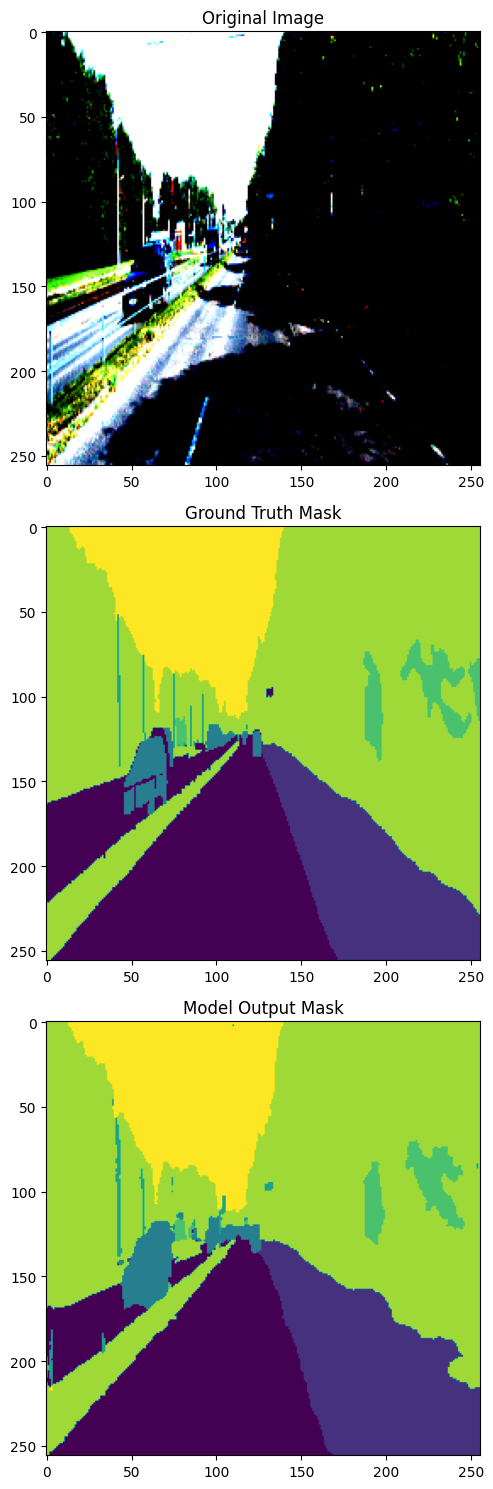

In [ ]:
visualize_result(0)

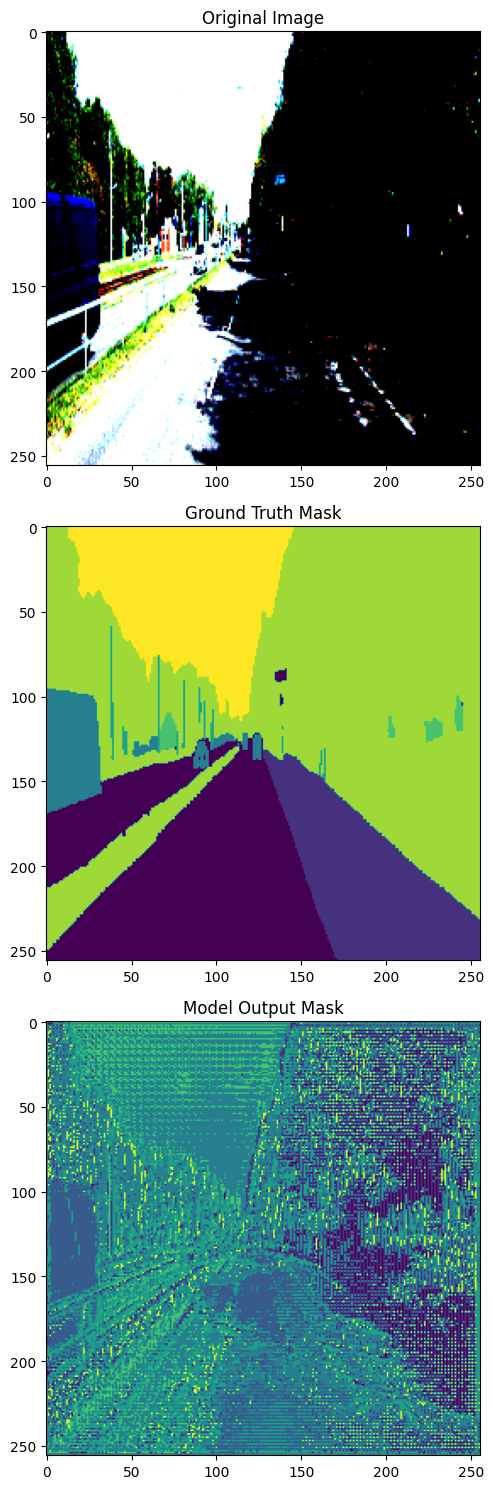

In [ ]:
visualize_result(15)

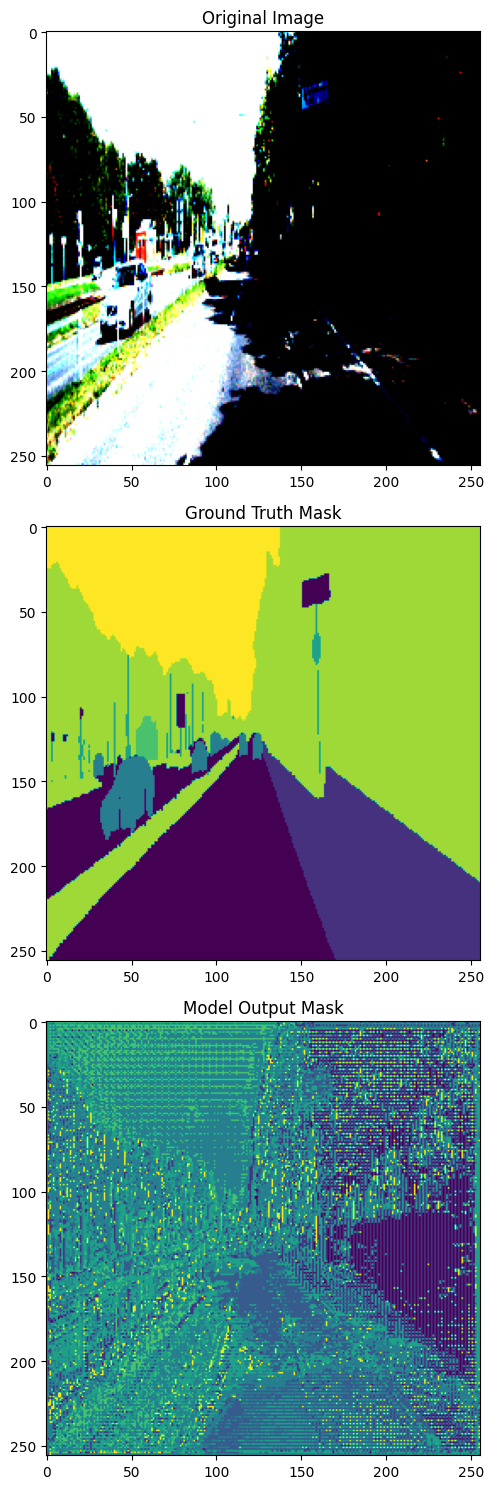

In [ ]:
visualize_result(31)

In [ ]:
NUM_EPOCHS = 40

In [ ]:
for i in range(num_ran_epochs, NUM_EPOCHS):
    print(f"Epoch {i+1}:")

    train_loss = train()
    val_loss = eval()

    model_saved = False

    if (val_loss < min_val_loss):
      print(f"Saved the {i+1}th model which had a val_loss of {val_loss}")
      torch.save(model, CHECKPOINTS_PTH + MODEL_NAME + CHECKPOINT_FEXT)
      min_val_loss = val_loss
      model_saved=True

    logger.add_row(
        train_loss=train_loss,
        val_loss=val_loss,
        lr=optim.param_groups[0]['lr'],
        model_saved=model_saved,
        train_batch_size=1,
        val_batch_size=1
    )

    lr_sch.step(val_loss)
    num_ran_epochs += 1

    print("")

Epoch 1:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:36<00:00,  3.86it/s, eval_loss=0.832]


Saved the 1th model which had a val_loss of 0.8322984593255179

Epoch 2:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:36<00:00,  3.82it/s, eval_loss=0.827]


Saved the 2th model which had a val_loss of 0.8266654193401337

Epoch 3:


...

  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:35<00:00,  3.92it/s, eval_loss=0.711]



Epoch 39:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:36<00:00,  3.88it/s, eval_loss=0.711]



Epoch 40:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:35<00:00,  3.94it/s, eval_loss=0.712]

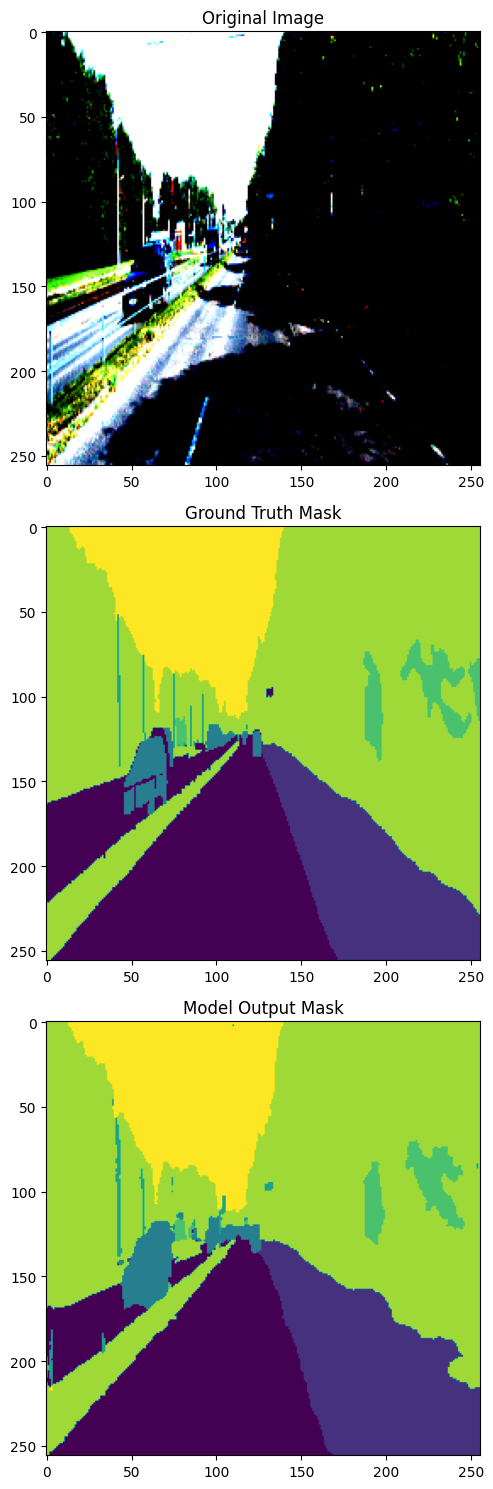

In [ ]:
visualize_result(0)

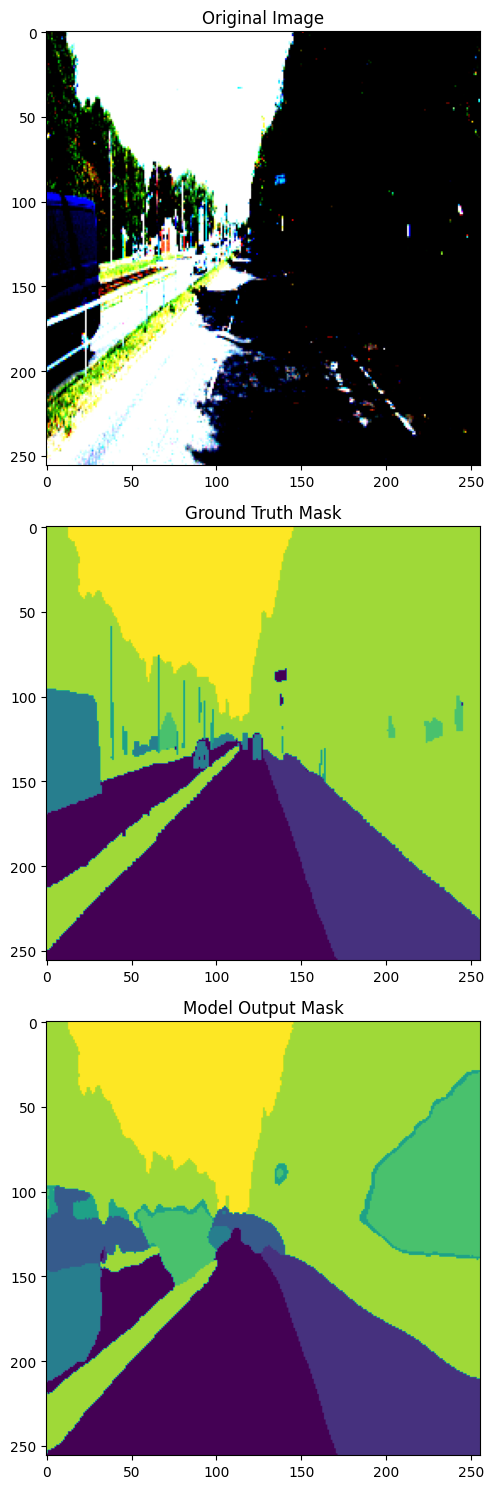

In [ ]:
visualize_result(15)

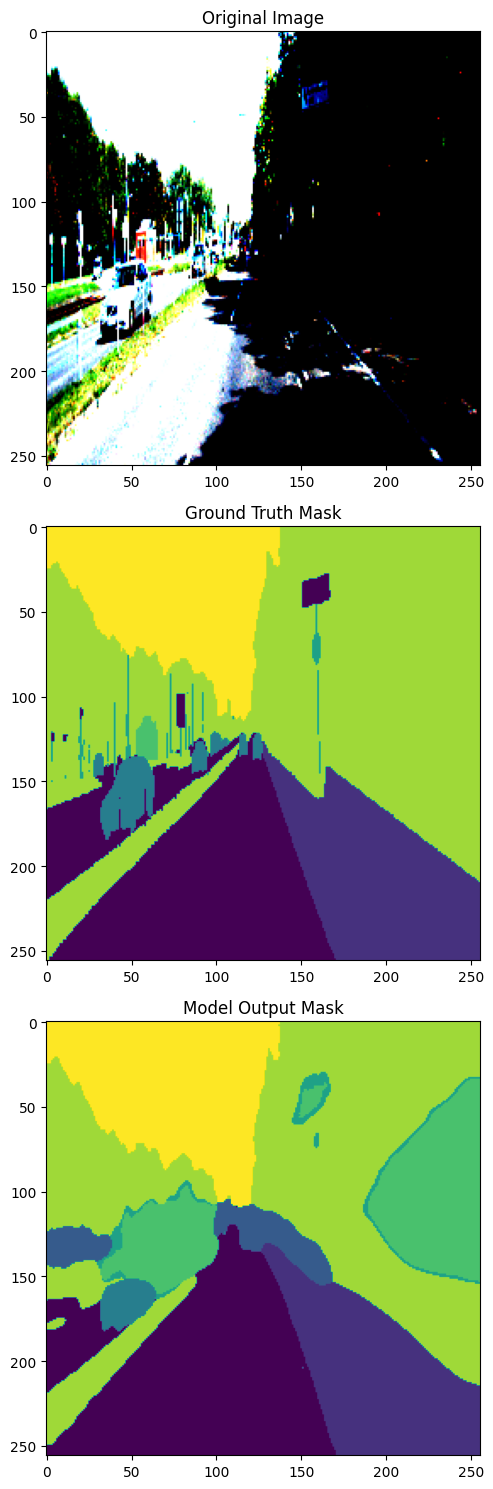

In [ ]:
visualize_result(31)

In [ ]:
model = torch.load(MODEL_CHECKPOINT_PTH).to(DEVICE)

In [ ]:
model.is_teacher_forcing = False

In [ ]:
optim = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
NUM_EPOCHS = 100

In [ ]:
for i in range(num_ran_epochs, NUM_EPOCHS):
    print(f"Epoch {i+1}:")

    train_loss = train()
    val_loss = eval()

    model_saved = False

    if (val_loss < min_val_loss):
      print(f"Saved the {i+1}th model which had a val_loss of {val_loss}")
      torch.save(model, CHECKPOINTS_PTH + MODEL_NAME + CHECKPOINT_FEXT)
      min_val_loss = val_loss
      model_saved=True

    logger.add_row(
        train_loss=train_loss,
        val_loss=val_loss,
        lr=optim.param_groups[0]['lr'],
        model_saved=model_saved,
        train_batch_size=1,
        val_batch_size=1
    )

    lr_sch.step(val_loss)
    num_ran_epochs += 1

    print("")

Epoch 41:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:34<00:00,  4.09it/s, eval_loss=0.695]



Epoch 42:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:34<00:00,  4.11it/s, eval_loss=0.68]


Saved the 42th model which had a val_loss of 0.6802387761218207

Epoch 43:


...


Epoch 99:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:34<00:00,  4.12it/s, eval_loss=0.418]



Epoch 100:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:34<00:00,  4.06it/s, eval_loss=0.415]


Saved the 100th model which had a val_loss of 0.4150222050292151



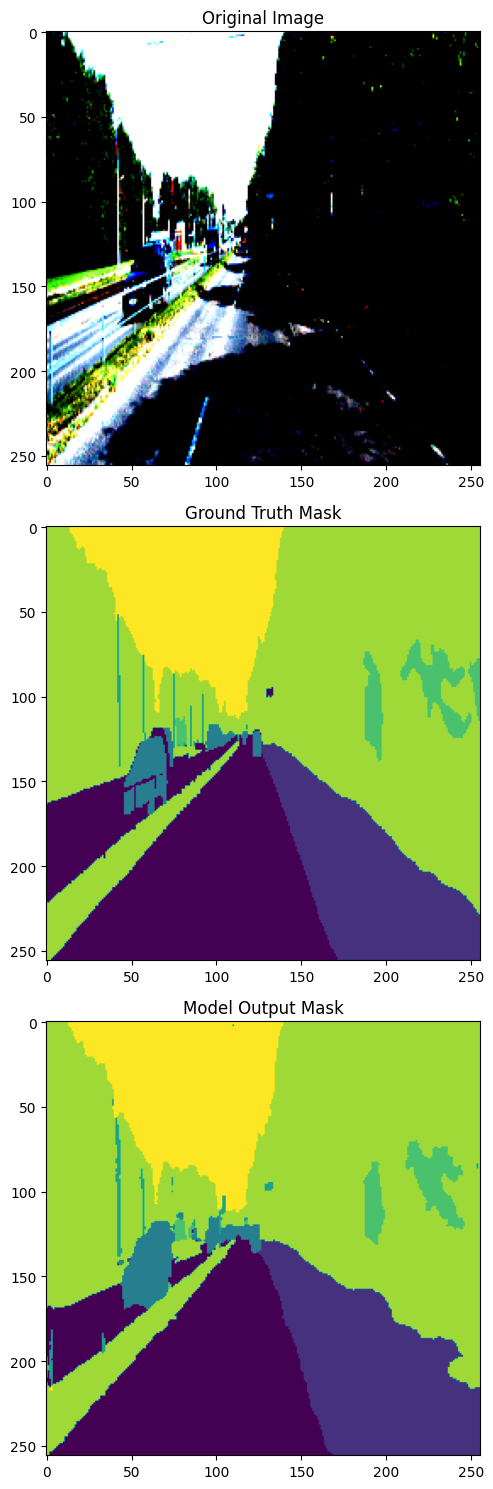

In [ ]:
visualize_result(0)

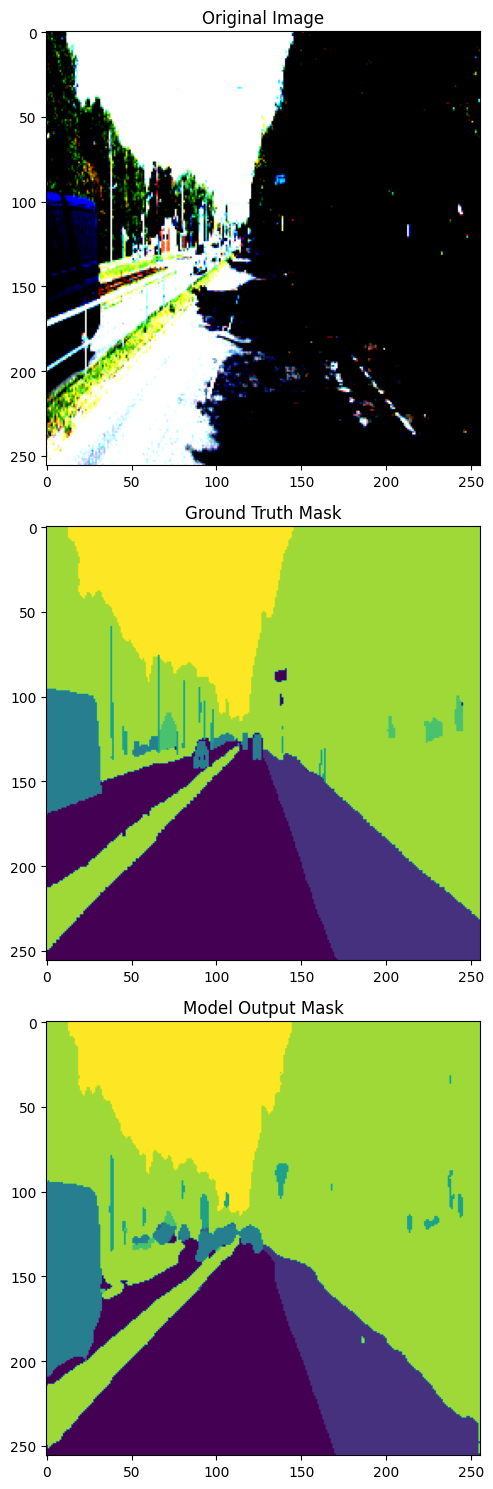

In [ ]:
visualize_result(15)

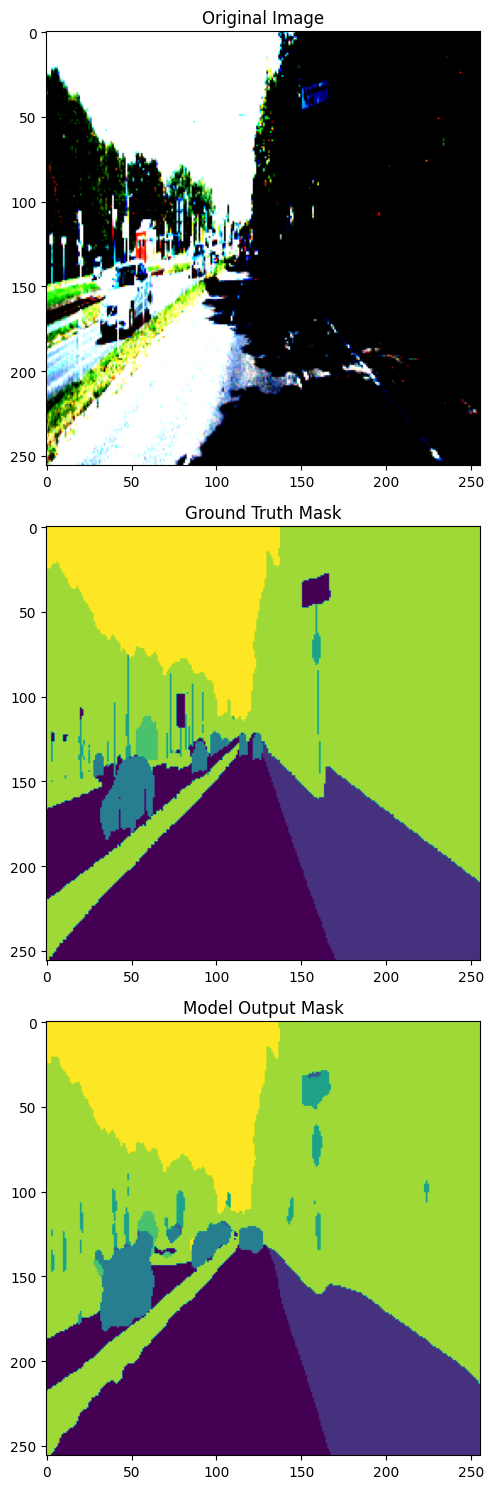

In [ ]:
visualize_result(31)

In [ ]:
NUM_EPOCHS = 150

In [ ]:
for i in range(num_ran_epochs, NUM_EPOCHS):
    print(f"Epoch {i+1}:")

    train_loss = train()
    val_loss = eval()

    model_saved = False

    if (val_loss < min_val_loss):
      print(f"Saved the {i+1}th model which had a val_loss of {val_loss}")
      torch.save(model, CHECKPOINTS_PTH + MODEL_NAME + CHECKPOINT_FEXT)
      min_val_loss = val_loss
      model_saved=True

    logger.add_row(
        train_loss=train_loss,
        val_loss=val_loss,
        lr=optim.param_groups[0]['lr'],
        model_saved=model_saved,
        train_batch_size=1,
        val_batch_size=1
    )

    lr_sch.step(val_loss)
    num_ran_epochs += 1

    print("")

Epoch 101:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:34<00:00,  4.10it/s, eval_loss=0.408]


Saved the 101th model which had a val_loss of 0.40806712465626854

Epoch 102:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:34<00:00,  4.09it/s, eval_loss=0.411]



Epoch 103:


...

  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:34<00:00,  4.04it/s, eval_loss=0.328]


Saved the 148th model which had a val_loss of 0.3279360063374043

Epoch 149:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:33<00:00,  4.12it/s, eval_loss=0.355]



Epoch 150:


  0%|          | 0/140 [00:00<?, ?it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
100%|██████████| 140/140 [00:34<00:00,  4.10it/s, eval_loss=0.372]

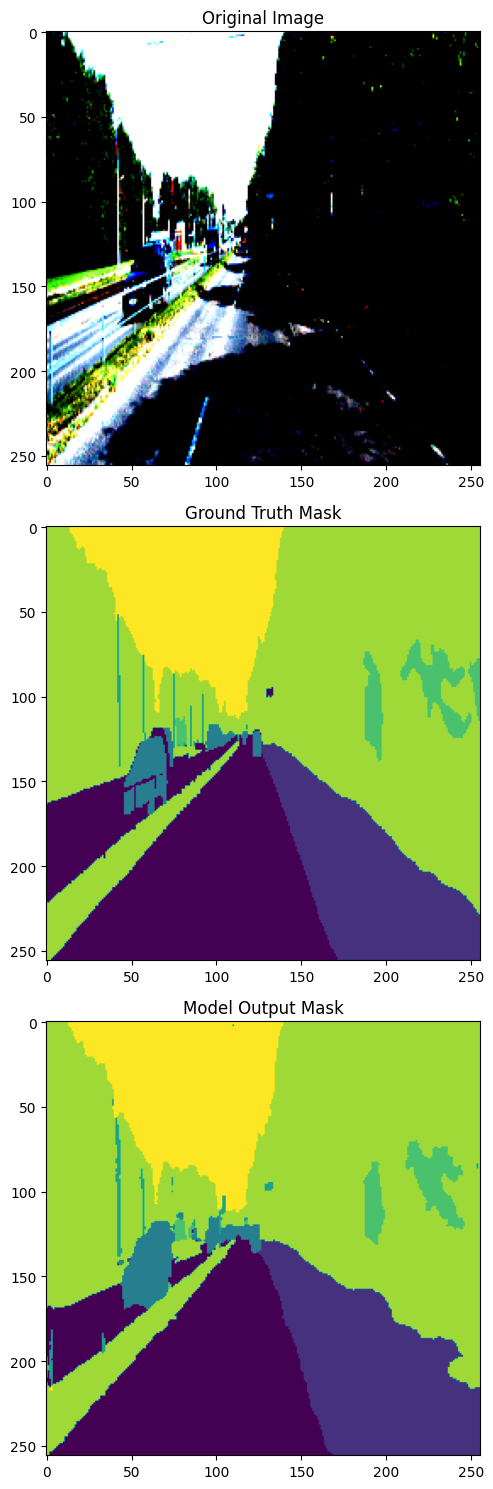

In [ ]:
visualize_result(0)

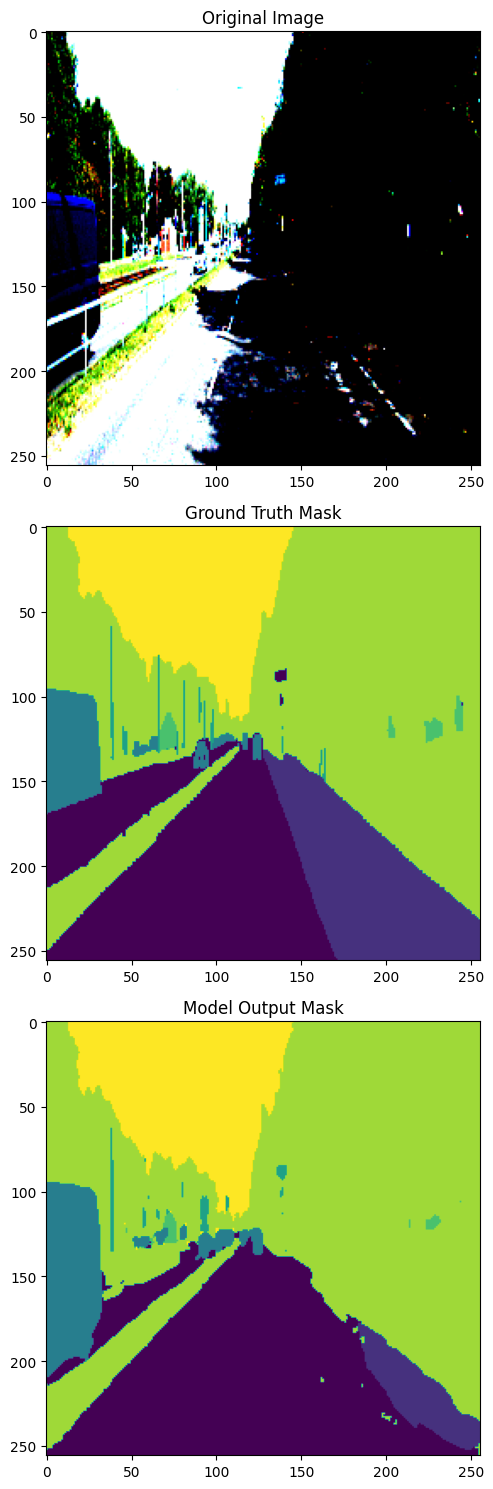

In [ ]:
visualize_result(15)

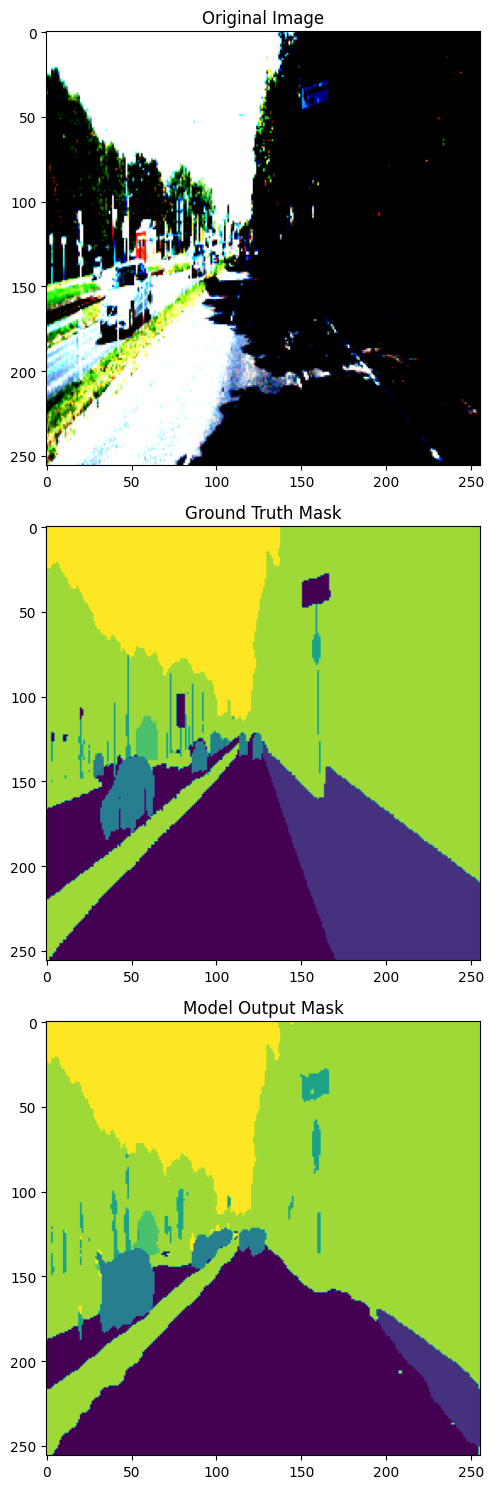

In [ ]:
visualize_result(31)

In [ ]:
NUM_EPOCHS = 200

In [ ]:
for i in range(num_ran_epochs, NUM_EPOCHS):
    print(f"Epoch {i+1}:")

    train_loss = train()
    val_loss = eval()

    model_saved = False

    if (val_loss < min_val_loss):
      print(f"Saved the {i+1}th model which had a val_loss of {val_loss}")
      torch.save(model, CHECKPOINTS_PTH + MODEL_NAME + CHECKPOINT_FEXT)
      min_val_loss = val_loss
      model_saved=True

    logger.add_row(
        train_loss=train_loss,
        val_loss=val_loss,
        lr=optim.param_groups[0]['lr'],
        model_saved=model_saved,
        train_batch_size=1,
        val_batch_size=1
    )

    lr_sch.step(val_loss)
    num_ran_epochs += 1

    print("")

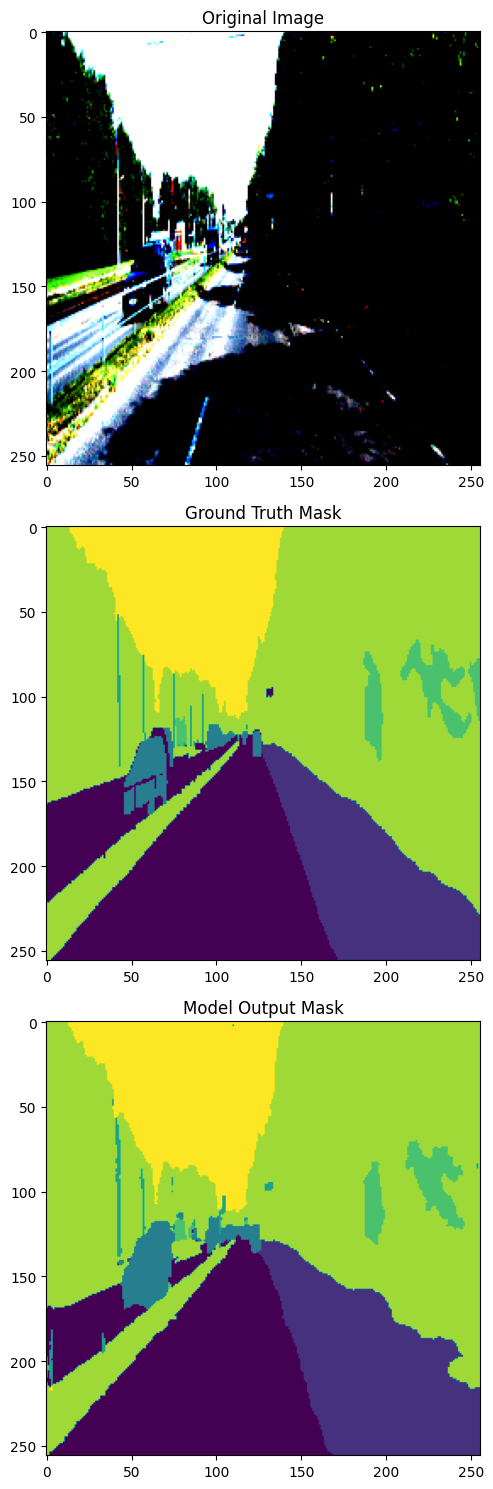

In [ ]:
visualize_result(0)

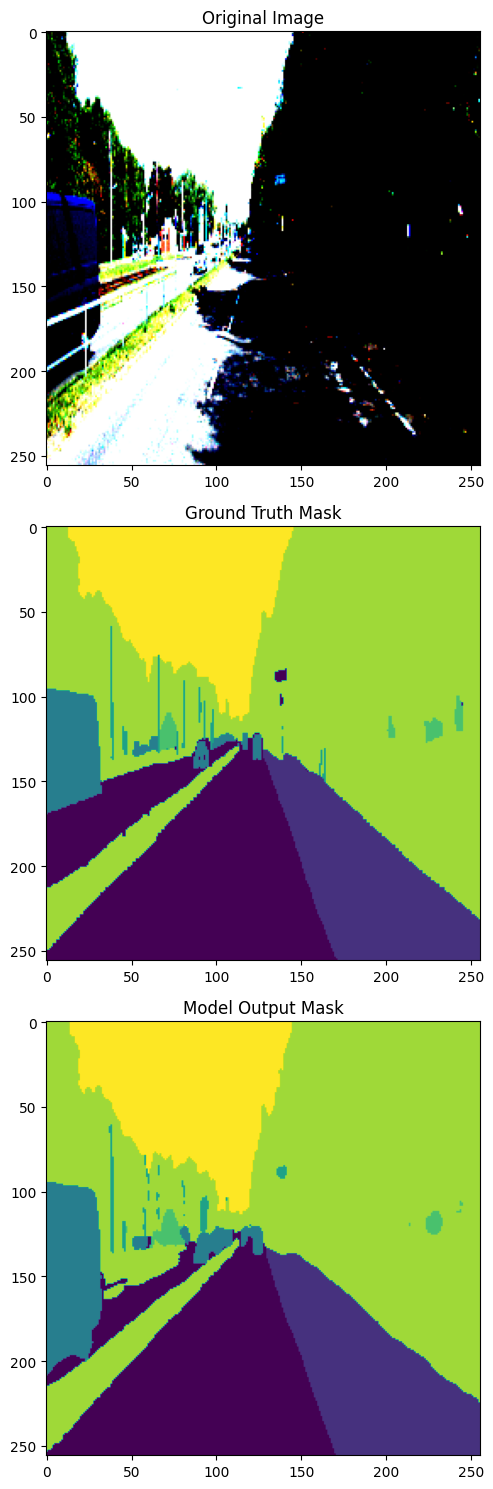

In [ ]:
visualize_result(15)

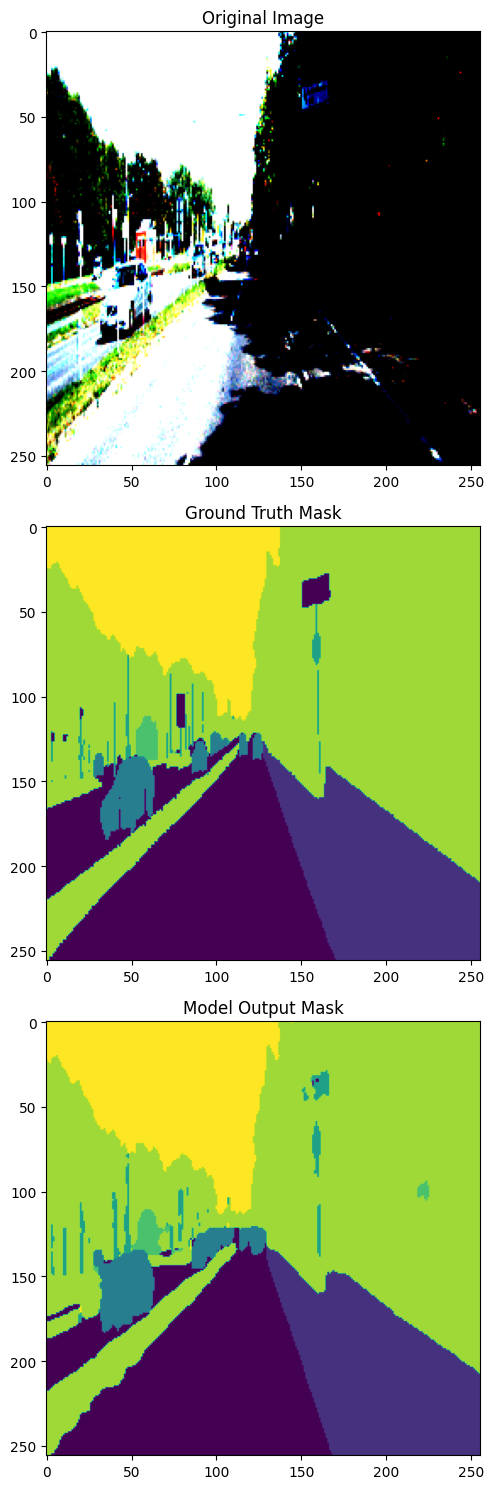

In [ ]:
visualize_result(31)